# Stock Price Prediction: CNN, RNN, LSTM & Transformer

This notebook pulls stock data (AAPL, GOOG, META, NVDA, TSLA) from GitHub, aligns all stocks to a common start date, and trains/validates/tests several deep learning models.

**Strategy:**
- **Align dates**: Trim all stocks to the latest common start date
- **Train**: 4 stocks from common start through end of 2023
- **Validate**: Those same 4 stocks from 2024 onward
- **Test**: The held-out 5th stock from 2024 onward

**Runtime**: Go to `Runtime > Change runtime type > T4 GPU` for faster training.

---
## 1. Setup & Installation

In [ ]:
!pip install -q torch torchvision numpy pandas scikit-learn matplotlib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import warnings
import math
import os

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


---
## 2. Configuration

**IMPORTANT**: Update `GITHUB_BASE_URL` and `FILE_NAMES` below to match your repo structure.

In [ ]:
# Which stock to hold out for final testing
HOLDOUT_STOCK = 'TSLA'

# Model hyperparameters
SEQUENCE_LENGTH = 60      # Number of past days to use as input
FORECAST_HORIZON = 1      # Predict 1 day ahead
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 0.001
TRAIN_CUTOFF = '2024-01-01'  # Train on data before this date

# Features to use from the CSV
FEATURE_COLS = ['Open', 'High', 'Low', 'Close', 'Volume']
TARGET_COL = 'Close'

print(f"Holdout stock for testing: {HOLDOUT_STOCK}")
print(f"Sequence length: {SEQUENCE_LENGTH}")
print(f"Training on data before: {TRAIN_CUTOFF}")

Holdout stock for testing: TSLA
Sequence length: 60
Training on data before: 2024-01-01


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 3. Load & Align Data from GitHub

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# UPDATE THIS to your actual Google Drive folder path
DRIVE_FOLDER = "/content/drive/MyDrive/DL4TS-Term-Project/"

FILE_NAMES = {
    'AAPL': 'Historical_Data_AAPL.csv',
    'GOOG': 'Historical_Data_GOOG.csv',
    'META': 'Historical_Data_META.csv',
    'NVDA': 'Historical_Data_NVDA.csv',
    'TSLA': 'Historical_Data_TSLA.csv',
}

def load_stock_data(folder, file_names):
    """Load all stock CSVs from Google Drive."""
    stocks = {}
    for ticker, fname in file_names.items():
        path = folder + fname
        print(f"Loading {ticker} from {path}...")
        df = pd.read_csv(path)
        df['Date'] = pd.to_datetime(df['Date'], utc=True)
        df['Date'] = df['Date'].dt.tz_localize(None)
        df = df.sort_values('Date').reset_index(drop=True)
        stocks[ticker] = df
        print(f"  {ticker}: {len(df)} rows, {df['Date'].min().date()} to {df['Date'].max().date()}")
    return stocks

raw_stocks = load_stock_data(DRIVE_FOLDER, FILE_NAMES)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading AAPL from /content/drive/MyDrive/DL4TS-Term-Project/Historical_Data_AAPL.csv...
  AAPL: 11383 rows, 1980-12-12 to 2026-02-11
Loading GOOG from /content/drive/MyDrive/DL4TS-Term-Project/Historical_Data_GOOG.csv...
  GOOG: 5405 rows, 2004-08-19 to 2026-02-11
Loading META from /content/drive/MyDrive/DL4TS-Term-Project/Historical_Data_META.csv...
  META: 3453 rows, 2012-05-18 to 2026-02-11
Loading NVDA from /content/drive/MyDrive/DL4TS-Term-Project/Historical_Data_NVDA.csv...
  NVDA: 6806 rows, 1999-01-22 to 2026-02-11
Loading TSLA from /content/drive/MyDrive/DL4TS-Term-Project/Historical_Data_TSLA.csv...
  TSLA: 3930 rows, 2010-06-29 to 2026-02-11


In [ ]:
def align_stocks(stocks_dict):
    """
    Align all stocks to the latest common start date.
    If AAPL starts 1982 but GOOG starts 2004, everyone starts from 2004.
    """
    # Find the latest start date across all stocks
    start_dates = {t: df['Date'].min() for t, df in stocks_dict.items()}
    common_start = max(start_dates.values())

    print(f"\nIndividual start dates:")
    for t, d in sorted(start_dates.items(), key=lambda x: x[1]):
        print(f"  {t}: {d.date()}")
    print(f"\nCommon start date (latest): {common_start.date()}")

    aligned = {}
    for ticker, df in stocks_dict.items():
        trimmed = df[df['Date'] >= common_start].copy().reset_index(drop=True)
        aligned[ticker] = trimmed
        print(f"  {ticker}: {len(trimmed)} rows after alignment")

    return aligned, common_start

stocks, common_start = align_stocks(raw_stocks)


Individual start dates:
  AAPL: 1980-12-12
  NVDA: 1999-01-22
  GOOG: 2004-08-19
  TSLA: 2010-06-29
  META: 2012-05-18

Common start date (latest): 2012-05-18
  AAPL: 3453 rows after alignment
  GOOG: 3453 rows after alignment
  META: 3453 rows after alignment
  NVDA: 3453 rows after alignment
  TSLA: 3453 rows after alignment


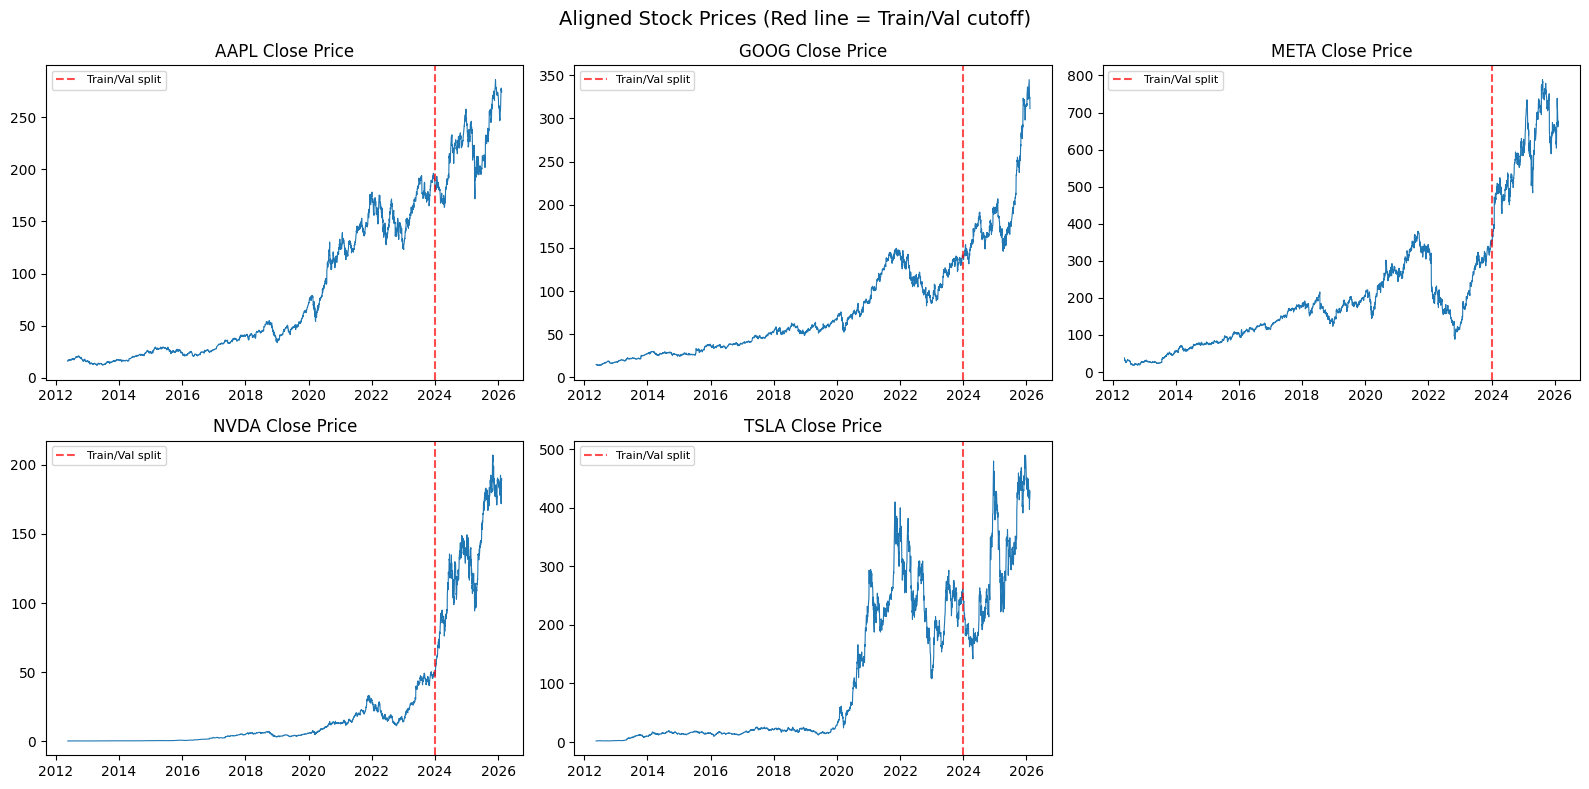

In [ ]:
# Quick visualization of aligned stock prices
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, (ticker, df) in enumerate(stocks.items()):
    axes[i].plot(df['Date'], df['Close'], linewidth=0.8)
    axes[i].set_title(f'{ticker} Close Price')
    axes[i].axvline(x=pd.Timestamp(TRAIN_CUTOFF), color='r', linestyle='--', alpha=0.7, label='Train/Val split')
    axes[i].legend(fontsize=8)
# Hide the extra subplot
if len(stocks) < len(axes):
    for j in range(len(stocks), len(axes)):
        axes[j].set_visible(False)
plt.suptitle('Aligned Stock Prices (Red line = Train/Val cutoff)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Data Preprocessing & Dataset Creation

In [ ]:
class StockDataset(Dataset):
    """PyTorch Dataset for windowed stock sequences."""
    def __init__(self, features, targets, seq_len):
        self.features = torch.FloatTensor(features)
        self.targets = torch.FloatTensor(targets)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.features) - self.seq_len

    def __getitem__(self, idx):
        x = self.features[idx:idx + self.seq_len]
        y = self.targets[idx + self.seq_len]
        return x, y


def prepare_data(stocks, holdout_ticker, feature_cols, target_col, train_cutoff, seq_len):
    """
    Prepare train/val/test datasets.
    - Train: all stocks except holdout, before train_cutoff
    - Val: all stocks except holdout, from train_cutoff onward
    - Test: holdout stock only, from train_cutoff onward

    Each stock is scaled independently using MinMaxScaler fit on its training portion.
    Returns datasets and scalers for inverse-transforming predictions.
    """
    train_feats, train_tgts = [], []
    val_feats, val_tgts = [], []
    test_feats, test_tgts = [], []

    scalers = {}  # Store scalers per stock for inverse transform
    target_idx = feature_cols.index(target_col)

    cutoff_date = pd.Timestamp(train_cutoff)

    for ticker, df in stocks.items():
        # Split by date
        train_mask = df['Date'] < cutoff_date
        val_mask = df['Date'] >= cutoff_date

        train_df = df[train_mask][feature_cols].values
        val_df = df[val_mask][feature_cols].values

        # Fit scaler on training data only
        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_df)
        val_scaled = scaler.transform(val_df)
        scalers[ticker] = scaler

        if ticker == holdout_ticker:
            # Holdout: only goes to test set (val portion)
            # But we need enough history, so we use end of training data as lead-in
            combined = np.concatenate([train_scaled[-seq_len:], val_scaled], axis=0)
            test_feats.append(combined)
            # Targets: only the val portion
            test_tgts.append(combined[:, target_idx])
            print(f"  {ticker} [TEST]:  {len(val_df)} val points (+ {seq_len} lead-in)")
        else:
            # Training stocks
            train_feats.append(train_scaled)
            train_tgts.append(train_scaled[:, target_idx])

            # Val: use end of train as lead-in for continuity
            combined_val = np.concatenate([train_scaled[-seq_len:], val_scaled], axis=0)
            val_feats.append(combined_val)
            val_tgts.append(combined_val[:, target_idx])

            print(f"  {ticker} [TRAIN]: {len(train_df)} train, {len(val_df)} val points")

    # Create PyTorch datasets by combining all train stocks
    # For training: concatenate sequences from all training stocks
    train_datasets = []
    for f, t in zip(train_feats, train_tgts):
        train_datasets.append(StockDataset(f, t, seq_len))
    train_dataset = torch.utils.data.ConcatDataset(train_datasets)

    val_datasets = []
    for f, t in zip(val_feats, val_tgts):
        val_datasets.append(StockDataset(f, t, seq_len))
    val_dataset = torch.utils.data.ConcatDataset(val_datasets)

    test_datasets = []
    for f, t in zip(test_feats, test_tgts):
        test_datasets.append(StockDataset(f, t, seq_len))
    test_dataset = torch.utils.data.ConcatDataset(test_datasets)

    print(f"\nDataset sizes:")
    print(f"  Train: {len(train_dataset)} sequences")
    print(f"  Val:   {len(val_dataset)} sequences")
    print(f"  Test:  {len(test_dataset)} sequences (holdout: {holdout_ticker})")

    return train_dataset, val_dataset, test_dataset, scalers


print(f"Preparing data with holdout={HOLDOUT_STOCK}...\n")
train_dataset, val_dataset, test_dataset, scalers = prepare_data(
    stocks, HOLDOUT_STOCK, FEATURE_COLS, TARGET_COL, TRAIN_CUTOFF, SEQUENCE_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

NUM_FEATURES = len(FEATURE_COLS)
print(f"\nInput shape per sample: ({SEQUENCE_LENGTH}, {NUM_FEATURES})")

Preparing data with holdout=TSLA...

  AAPL [TRAIN]: 2923 train, 530 val points
  GOOG [TRAIN]: 2923 train, 530 val points
  META [TRAIN]: 2923 train, 530 val points
  NVDA [TRAIN]: 2923 train, 530 val points
  TSLA [TEST]:  530 val points (+ 60 lead-in)

Dataset sizes:
  Train: 11452 sequences
  Val:   2120 sequences
  Test:  530 sequences (holdout: TSLA)

Input shape per sample: (60, 5)


---
## 5. Training & Evaluation Utilities

In [ ]:
def train_model(model, train_loader, val_loader, epochs, lr, model_name='Model'):
    """Train a model and return training history."""
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    PATIENCE = 10

    for epoch in range(epochs):
        # Training
        model.train()
        train_losses = []
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(x_batch)
            loss = criterion(pred.squeeze(), y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        # Validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                pred = model(x_batch)
                loss = criterion(pred.squeeze(), y_batch)
                val_losses.append(loss.item())

        avg_train = np.mean(train_losses)
        avg_val = np.mean(val_losses)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)

        scheduler.step(avg_val)

        # Early stopping
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_train:.6f} | Val Loss: {avg_val:.6f}")

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


def evaluate_model(model, loader, label='Test'):
    """Evaluate model and return predictions and targets."""
    model.eval()
    all_preds, all_targets = [], []
    criterion = nn.MSELoss()
    losses = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            pred = model(x_batch)
            loss = criterion(pred.squeeze(), y_batch)
            losses.append(loss.item())
            all_preds.extend(pred.squeeze().cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    mse = np.mean(losses)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(np.array(all_preds) - np.array(all_targets)))

    print(f"  {label} - MSE: {mse:.6f} | RMSE: {rmse:.6f} | MAE: {mae:.6f}")
    return np.array(all_preds), np.array(all_targets), {'mse': mse, 'rmse': rmse, 'mae': mae}


def plot_training_history(history, title):
    """Plot training and validation loss curves."""
    plt.figure(figsize=(8, 4))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(f'{title} - Training History')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_predictions(preds, targets, title):
    """Plot predicted vs actual values."""
    plt.figure(figsize=(12, 4))
    plt.plot(targets, label='Actual', alpha=0.8)
    plt.plot(preds, label='Predicted', alpha=0.8)
    plt.xlabel('Time Step')
    plt.ylabel('Normalized Close Price')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

---
## 6. Model Definitions

### 6a. CNN Model

In [ ]:
class CNNModel(nn.Module):
    """
    1D Convolutional Neural Network for time series prediction.
    Uses stacked Conv1D layers with increasing dilation to capture
    patterns at multiple time scales.
    """
    def __init__(self, num_features, seq_len):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv1d(num_features, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(128, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()

        # Calculate flattened size after pooling
        self.flat_size = 64 * (seq_len // 4)  # Two MaxPool1d(2) layers
        self.fc1 = nn.Linear(self.flat_size, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        # x: (batch, seq_len, features) -> transpose to (batch, features, seq_len)
        x = x.transpose(1, 2)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout(self.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

print("CNN Model defined.")
cnn_model = CNNModel(NUM_FEATURES, SEQUENCE_LENGTH)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"Total parameters: {total_params:,}")

CNN Model defined.
Total parameters: 174,017


### 6b. RNN Model

In [ ]:
class RNNModel(nn.Module):
    """
    Vanilla RNN (Elman network) for time series prediction.
    Uses stacked RNN layers with dropout.
    """
    def __init__(self, num_features, hidden_size=128, num_layers=2):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2,
            nonlinearity='tanh'
        )
        self.dropout = nn.Dropout(0.2)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (batch, seq_len, features)
        out, _ = self.rnn(x)
        out = out[:, -1, :]  # Take last time step
        out = self.dropout(self.relu(self.fc1(out)))
        out = self.fc2(out)
        return out

print("RNN Model defined.")
rnn_model = RNNModel(NUM_FEATURES)
total_params = sum(p.numel() for p in rnn_model.parameters())
print(f"Total parameters: {total_params:,}")

RNN Model defined.
Total parameters: 58,625


### 6c. LSTM Model

In [ ]:
class LSTMModel(nn.Module):
    """
    LSTM (Long Short-Term Memory) for time series prediction.
    Better at capturing long-range dependencies than vanilla RNN.
    Uses bidirectional LSTM and attention-like final layer pooling.
    """
    def __init__(self, num_features, hidden_size=128, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2,
            bidirectional=False
        )
        self.dropout = nn.Dropout(0.2)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        out = out[:, -1, :]  # Last time step output
        out = self.dropout(self.relu(self.fc1(out)))
        out = self.fc2(out)
        return out

print("LSTM Model defined.")
lstm_model = LSTMModel(NUM_FEATURES)
total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"Total parameters: {total_params:,}")

LSTM Model defined.
Total parameters: 209,537


### 6d. GRU Model

In [ ]:
class GRUModel(nn.Module):
    """
    GRU (Gated Recurrent Unit) for time series prediction.
    Simpler than LSTM but often comparable in performance.
    """
    def __init__(self, num_features, hidden_size=128, num_layers=2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )
        self.dropout = nn.Dropout(0.2)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.dropout(self.relu(self.fc1(out)))
        out = self.fc2(out)
        return out

print("GRU Model defined.")
gru_model = GRUModel(NUM_FEATURES)
total_params = sum(p.numel() for p in gru_model.parameters())
print(f"Total parameters: {total_params:,}")

GRU Model defined.
Total parameters: 159,233


### 6e. Transformer Model

In [ ]:
class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding."""
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerModel(nn.Module):
    """
    Transformer encoder for time series prediction.
    Uses multi-head self-attention to capture complex temporal patterns.
    """
    def __init__(self, num_features, d_model=64, nhead=4, num_layers=3, dim_feedforward=256, seq_len=60):
        super(TransformerModel, self).__init__()
        self.input_proj = nn.Linear(num_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=seq_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=0.1,
            batch_first=True,
            activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.dropout = nn.Dropout(0.1)
        self.fc1 = nn.Linear(d_model * seq_len, 128)
        self.fc2 = nn.Linear(128, 1)
        self.relu = nn.ReLU()
        self.seq_len = seq_len

    def forward(self, x):
        # x: (batch, seq_len, features)
        x = self.input_proj(x)  # Project to d_model dimensions
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x.reshape(x.size(0), -1)  # Flatten all time steps
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

print("Transformer Model defined.")
transformer_model = TransformerModel(NUM_FEATURES, seq_len=SEQUENCE_LENGTH)
total_params = sum(p.numel() for p in transformer_model.parameters())
print(f"Total parameters: {total_params:,}")

Transformer Model defined.
Total parameters: 642,113


---
## 7. Train CNN

TRAINING: CNN
  Epoch   1/50 | Train Loss: 0.014735 | Val Loss: 0.033310
  Epoch   5/50 | Train Loss: 0.002996 | Val Loss: 0.020234
  Epoch  10/50 | Train Loss: 0.002707 | Val Loss: 0.068623
  Epoch  15/50 | Train Loss: 0.002501 | Val Loss: 0.005196
  Epoch  20/50 | Train Loss: 0.002353 | Val Loss: 0.004340
  Epoch  25/50 | Train Loss: 0.002096 | Val Loss: 0.015507
  Epoch  30/50 | Train Loss: 0.001957 | Val Loss: 0.011572
  Early stopping at epoch 31


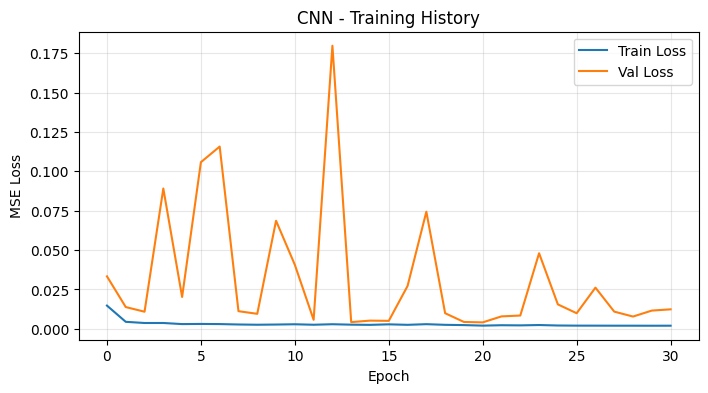


CNN Validation Results:
  Validation - MSE: 0.012363 | RMSE: 0.111190 | MAE: 0.081622

CNN Test Results (Holdout: TSLA):
  Test - MSE: 0.001518 | RMSE: 0.038958 | MAE: 0.029489


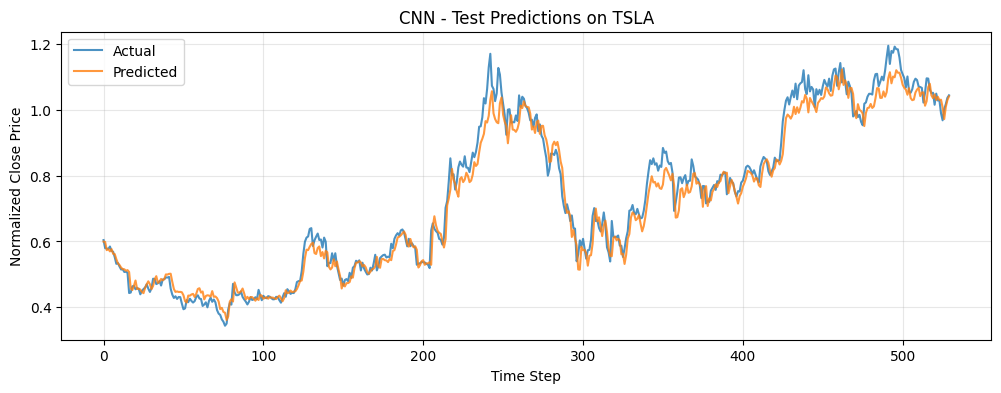

In [ ]:
print("="*60)
print("TRAINING: CNN")
print("="*60)
cnn_model = CNNModel(NUM_FEATURES, SEQUENCE_LENGTH)
cnn_model, cnn_history = train_model(cnn_model, train_loader, val_loader, EPOCHS, LEARNING_RATE, 'CNN')
plot_training_history(cnn_history, 'CNN')

print("\nCNN Validation Results:")
cnn_val_preds, cnn_val_targets, cnn_val_metrics = evaluate_model(cnn_model, val_loader, 'Validation')

print(f"\nCNN Test Results (Holdout: {HOLDOUT_STOCK}):")
cnn_test_preds, cnn_test_targets, cnn_test_metrics = evaluate_model(cnn_model, test_loader, 'Test')

plot_predictions(cnn_test_preds, cnn_test_targets, f'CNN - Test Predictions on {HOLDOUT_STOCK}')

---
## 8. Train RNN

TRAINING: RNN
  Epoch   1/50 | Train Loss: 0.008749 | Val Loss: 0.500068
  Epoch   5/50 | Train Loss: 0.001866 | Val Loss: 0.310349
  Epoch  10/50 | Train Loss: 0.001355 | Val Loss: 0.398064
  Epoch  15/50 | Train Loss: 0.001122 | Val Loss: 0.395711
  Early stopping at epoch 15


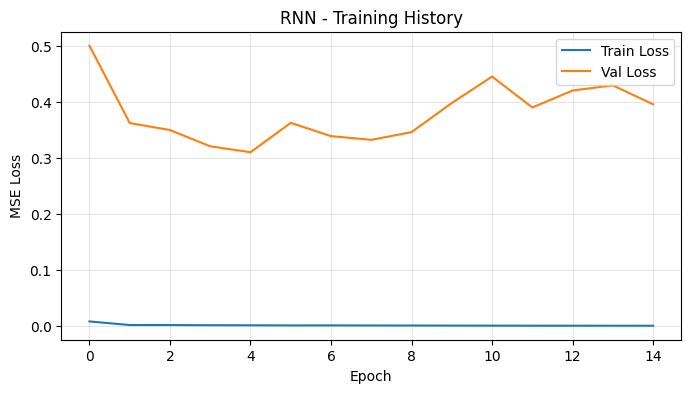


RNN Validation Results:
  Validation - MSE: 0.395711 | RMSE: 0.629055 | MAE: 0.333125

RNN Test Results (Holdout: TSLA):
  Test - MSE: 0.001404 | RMSE: 0.037474 | MAE: 0.027385


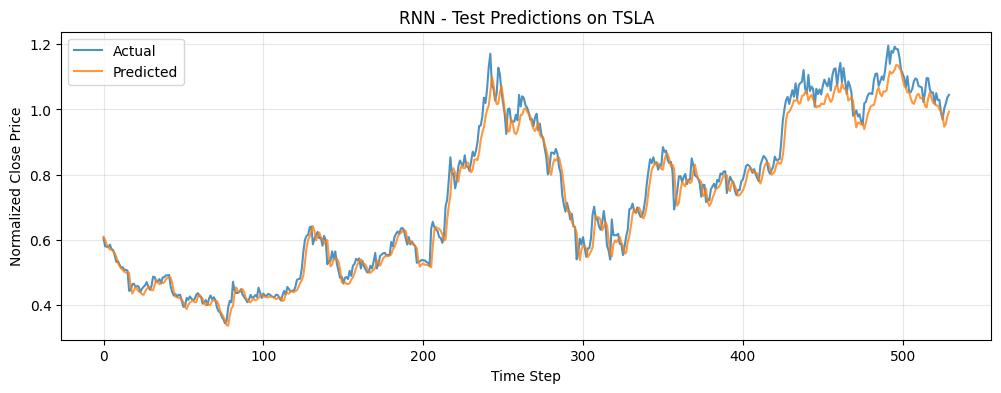

In [ ]:
print("="*60)
print("TRAINING: RNN")
print("="*60)
rnn_model = RNNModel(NUM_FEATURES)
rnn_model, rnn_history = train_model(rnn_model, train_loader, val_loader, EPOCHS, LEARNING_RATE, 'RNN')
plot_training_history(rnn_history, 'RNN')

print("\nRNN Validation Results:")
rnn_val_preds, rnn_val_targets, rnn_val_metrics = evaluate_model(rnn_model, val_loader, 'Validation')

print(f"\nRNN Test Results (Holdout: {HOLDOUT_STOCK}):")
rnn_test_preds, rnn_test_targets, rnn_test_metrics = evaluate_model(rnn_model, test_loader, 'Test')

plot_predictions(rnn_test_preds, rnn_test_targets, f'RNN - Test Predictions on {HOLDOUT_STOCK}')

---
## 9. Train LSTM

TRAINING: LSTM
  Epoch   1/50 | Train Loss: 0.010929 | Val Loss: 0.673472
  Epoch   5/50 | Train Loss: 0.002075 | Val Loss: 0.469169
  Epoch  10/50 | Train Loss: 0.001464 | Val Loss: 0.340209
  Epoch  15/50 | Train Loss: 0.001471 | Val Loss: 0.313773
  Epoch  20/50 | Train Loss: 0.001330 | Val Loss: 0.278304
  Epoch  25/50 | Train Loss: 0.001239 | Val Loss: 0.283576
  Early stopping at epoch 27


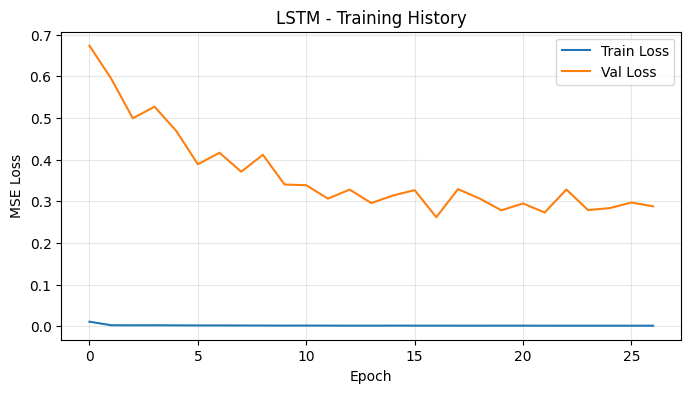


LSTM Validation Results:
  Validation - MSE: 0.287823 | RMSE: 0.536491 | MAE: 0.278012

LSTM Test Results (Holdout: TSLA):
  Test - MSE: 0.001005 | RMSE: 0.031701 | MAE: 0.024019


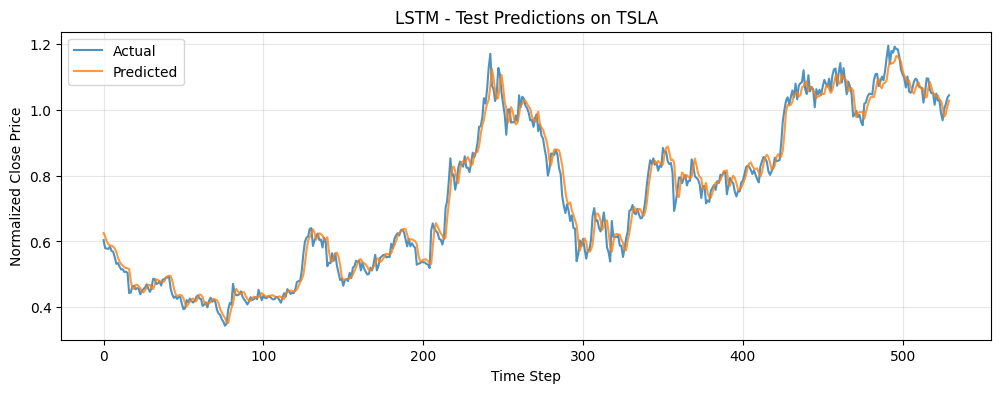

In [ ]:
print("="*60)
print("TRAINING: LSTM")
print("="*60)
lstm_model = LSTMModel(NUM_FEATURES)
lstm_model, lstm_history = train_model(lstm_model, train_loader, val_loader, EPOCHS, LEARNING_RATE, 'LSTM')
plot_training_history(lstm_history, 'LSTM')

print("\nLSTM Validation Results:")
lstm_val_preds, lstm_val_targets, lstm_val_metrics = evaluate_model(lstm_model, val_loader, 'Validation')

print(f"\nLSTM Test Results (Holdout: {HOLDOUT_STOCK}):")
lstm_test_preds, lstm_test_targets, lstm_test_metrics = evaluate_model(lstm_model, test_loader, 'Test')

plot_predictions(lstm_test_preds, lstm_test_targets, f'LSTM - Test Predictions on {HOLDOUT_STOCK}')

---
## 10. Train GRU

TRAINING: GRU
  Epoch   1/50 | Train Loss: 0.010220 | Val Loss: 0.410315
  Epoch   5/50 | Train Loss: 0.002300 | Val Loss: 0.257522
  Epoch  10/50 | Train Loss: 0.001586 | Val Loss: 0.253867
  Epoch  15/50 | Train Loss: 0.001269 | Val Loss: 0.223139
  Epoch  20/50 | Train Loss: 0.001150 | Val Loss: 0.266226
  Epoch  25/50 | Train Loss: 0.000997 | Val Loss: 0.247262
  Early stopping at epoch 27


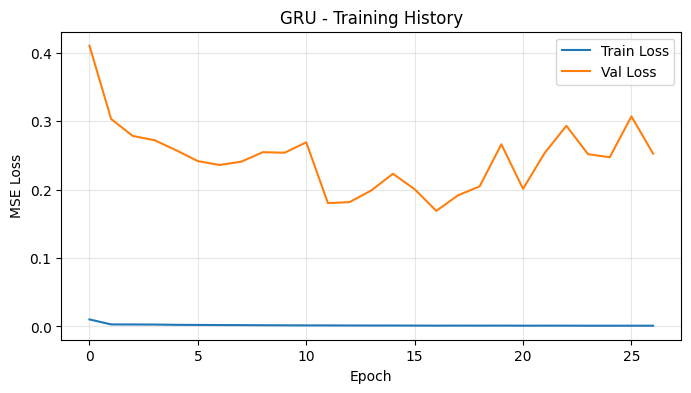


GRU Validation Results:
  Validation - MSE: 0.252587 | RMSE: 0.502580 | MAE: 0.245171

GRU Test Results (Holdout: TSLA):
  Test - MSE: 0.000948 | RMSE: 0.030795 | MAE: 0.023333


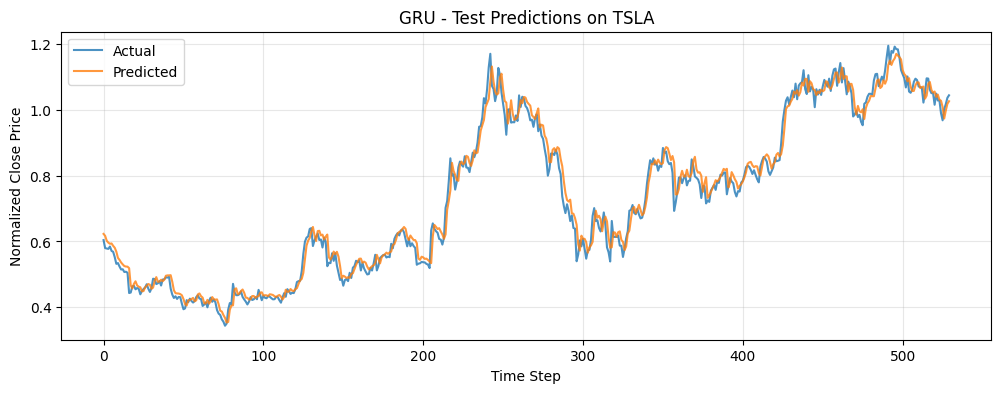

In [ ]:
print("="*60)
print("TRAINING: GRU")
print("="*60)
gru_model = GRUModel(NUM_FEATURES)
gru_model, gru_history = train_model(gru_model, train_loader, val_loader, EPOCHS, LEARNING_RATE, 'GRU')
plot_training_history(gru_history, 'GRU')

print("\nGRU Validation Results:")
gru_val_preds, gru_val_targets, gru_val_metrics = evaluate_model(gru_model, val_loader, 'Validation')

print(f"\nGRU Test Results (Holdout: {HOLDOUT_STOCK}):")
gru_test_preds, gru_test_targets, gru_test_metrics = evaluate_model(gru_model, test_loader, 'Test')

plot_predictions(gru_test_preds, gru_test_targets, f'GRU - Test Predictions on {HOLDOUT_STOCK}')

---
## 11. Train Transformer

TRAINING: Transformer
  Epoch   1/50 | Train Loss: 0.072289 | Val Loss: 0.495003
  Epoch   5/50 | Train Loss: 0.003643 | Val Loss: 0.174267
  Epoch  10/50 | Train Loss: 0.002688 | Val Loss: 0.369729
  Early stopping at epoch 14


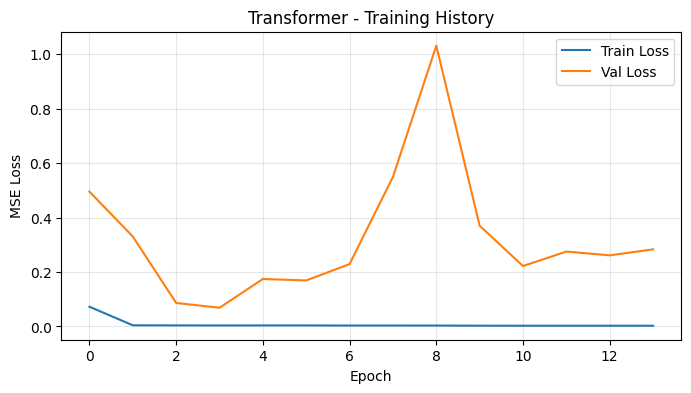


Transformer Validation Results:
  Validation - MSE: 0.283094 | RMSE: 0.532066 | MAE: 0.348001

Transformer Test Results (Holdout: TSLA):
  Test - MSE: 0.003474 | RMSE: 0.058943 | MAE: 0.042060


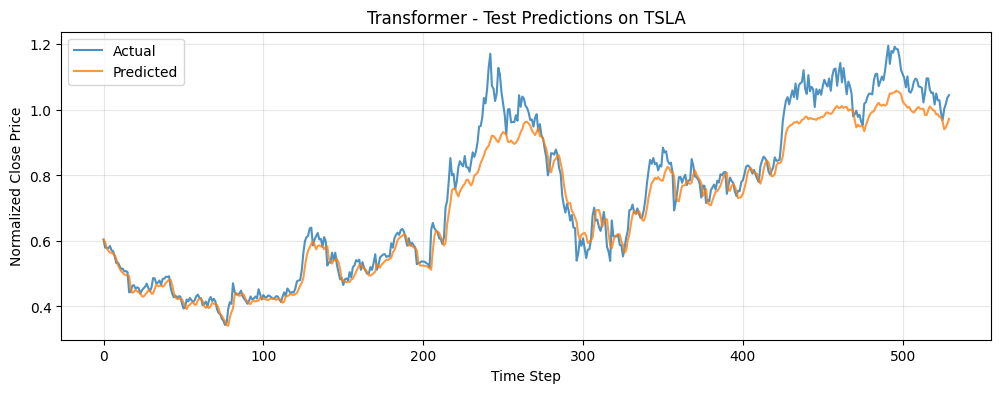

In [ ]:
print("="*60)
print("TRAINING: Transformer")
print("="*60)
transformer_model = TransformerModel(NUM_FEATURES, seq_len=SEQUENCE_LENGTH)
transformer_model, transformer_history = train_model(
    transformer_model, train_loader, val_loader, EPOCHS, LEARNING_RATE * 0.5, 'Transformer'
)
plot_training_history(transformer_history, 'Transformer')

print("\nTransformer Validation Results:")
tf_val_preds, tf_val_targets, tf_val_metrics = evaluate_model(transformer_model, val_loader, 'Validation')

print(f"\nTransformer Test Results (Holdout: {HOLDOUT_STOCK}):")
tf_test_preds, tf_test_targets, tf_test_metrics = evaluate_model(transformer_model, test_loader, 'Test')

plot_predictions(tf_test_preds, tf_test_targets, f'Transformer - Test Predictions on {HOLDOUT_STOCK}')

---
## 12. Final Comparison

In [ ]:
# Collect all results
results = {
    'CNN':         {'val': cnn_val_metrics,  'test': cnn_test_metrics},
    'RNN':         {'val': rnn_val_metrics,  'test': rnn_test_metrics},
    'LSTM':        {'val': lstm_val_metrics, 'test': lstm_test_metrics},
    'GRU':         {'val': gru_val_metrics,  'test': gru_test_metrics},
    'Transformer': {'val': tf_val_metrics,   'test': tf_test_metrics},
}

# Print comparison table
print("="*80)
print(f"FINAL RESULTS COMPARISON (Holdout stock: {HOLDOUT_STOCK})")
print("="*80)
print(f"{'Model':<15} | {'Val MSE':>10} | {'Val RMSE':>10} | {'Val MAE':>10} | {'Test MSE':>10} | {'Test RMSE':>10} | {'Test MAE':>10}")
print("-"*95)
for model_name, metrics in results.items():
    v, t = metrics['val'], metrics['test']
    print(f"{model_name:<15} | {v['mse']:>10.6f} | {v['rmse']:>10.6f} | {v['mae']:>10.6f} | {t['mse']:>10.6f} | {t['rmse']:>10.6f} | {t['mae']:>10.6f}")

# Find best model
best_model = min(results.items(), key=lambda x: x[1]['test']['rmse'])
print(f"\nBest model on test set (by RMSE): {best_model[0]} (RMSE: {best_model[1]['test']['rmse']:.6f})")

FINAL RESULTS COMPARISON (Holdout stock: TSLA)
Model           |    Val MSE |   Val RMSE |    Val MAE |   Test MSE |  Test RMSE |   Test MAE
-----------------------------------------------------------------------------------------------
CNN             |   0.012363 |   0.111190 |   0.081622 |   0.001518 |   0.038958 |   0.029489
RNN             |   0.395711 |   0.629055 |   0.333125 |   0.001404 |   0.037474 |   0.027385
LSTM            |   0.287823 |   0.536491 |   0.278012 |   0.001005 |   0.031701 |   0.024019
GRU             |   0.252587 |   0.502580 |   0.245171 |   0.000948 |   0.030795 |   0.023333
Transformer     |   0.283094 |   0.532066 |   0.348001 |   0.003474 |   0.058943 |   0.042060

Best model on test set (by RMSE): GRU (RMSE: 0.030795)


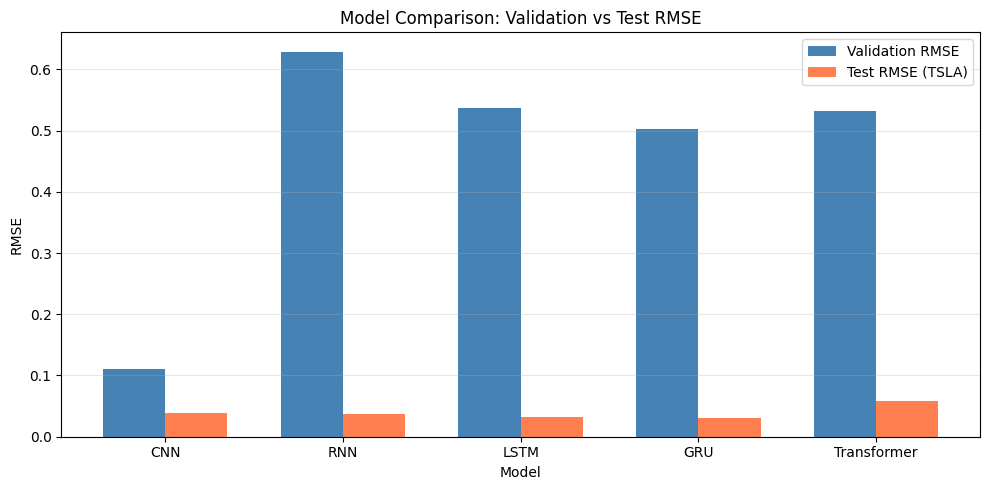

In [ ]:
# Bar chart comparison
model_names = list(results.keys())
val_rmse = [results[m]['val']['rmse'] for m in model_names]
test_rmse = [results[m]['test']['rmse'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, val_rmse, width, label='Validation RMSE', color='steelblue')
bars2 = ax.bar(x + width/2, test_rmse, width, label=f'Test RMSE ({HOLDOUT_STOCK})', color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('RMSE')
ax.set_title('Model Comparison: Validation vs Test RMSE')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

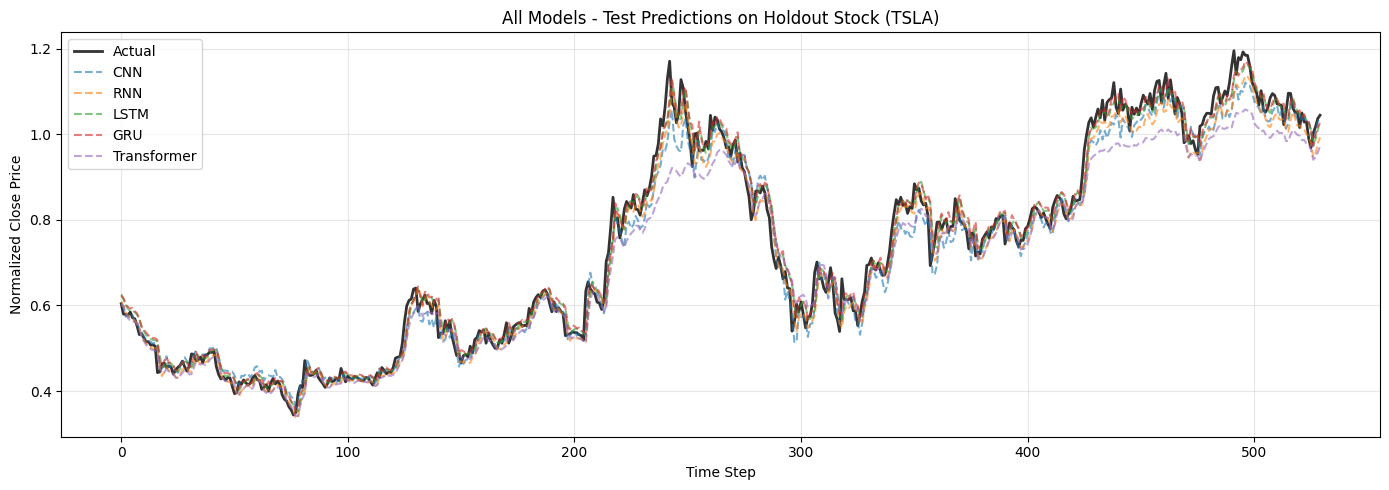


Done! All models trained, validated, and tested.


In [ ]:
# Overlay all model test predictions
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cnn_test_targets, 'k-', alpha=0.8, linewidth=2, label='Actual')
ax.plot(cnn_test_preds, '--', alpha=0.6, label='CNN')
ax.plot(rnn_test_preds, '--', alpha=0.6, label='RNN')
ax.plot(lstm_test_preds, '--', alpha=0.6, label='LSTM')
ax.plot(gru_test_preds, '--', alpha=0.6, label='GRU')
ax.plot(tf_test_preds, '--', alpha=0.6, label='Transformer')
ax.set_xlabel('Time Step')
ax.set_ylabel('Normalized Close Price')
ax.set_title(f'All Models - Test Predictions on Holdout Stock ({HOLDOUT_STOCK})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nDone! All models trained, validated, and tested.")

## 13: Naive Model Comparison

REALITY CHECK: All models vs 'Tomorrow = Today' baseline
Test set: TSLA (2024+)

Model               Test RMSE   Test MAE   vs Naive RMSE   Beats Naive?
----------------------------------------------------------------------
NAIVE (copy yday)    0.028096   0.020498             ---       BASELINE
CNN                  0.038958   0.029489          -38.7%           ✗ No
RNN                  0.037474   0.027385          -33.4%           ✗ No
LSTM                 0.031701   0.024019          -12.8%           ✗ No
GRU                  0.030795   0.023333           -9.6%           ✗ No
Transformer          0.058943   0.042060         -109.8%           ✗ No

  If improvement is small (< 10%), the model is mostly just copying yesterday's price.


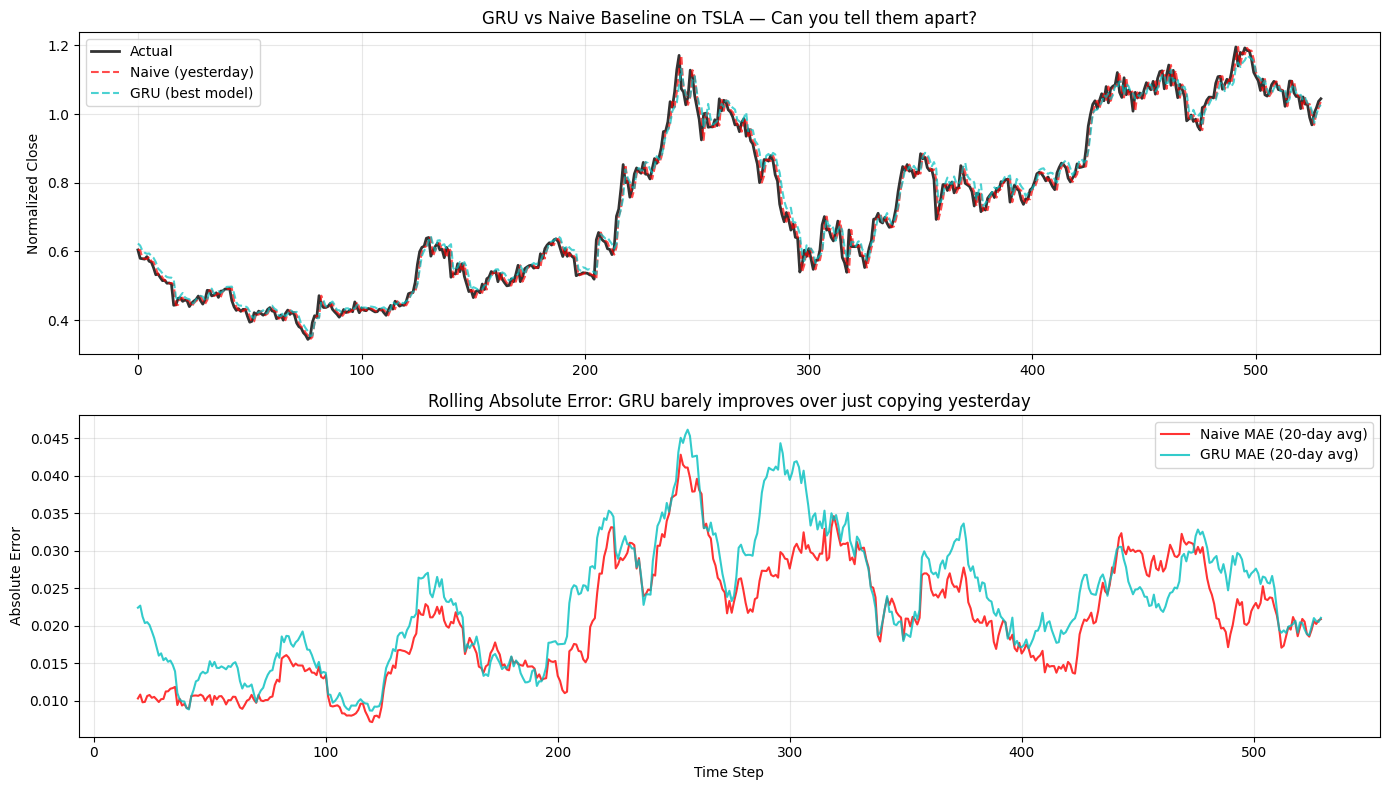


CORRELATION: How similar are model outputs to naive?
  1.0 = identical to naive, 0.0 = completely different

  CNN             r = 0.9959  ███████████████████████████████████████
  RNN             r = 0.9978  ███████████████████████████████████████
  LSTM            r = 0.9975  ███████████████████████████████████████
  GRU             r = 0.9984  ███████████████████████████████████████
  Transformer     r = 0.9907  ███████████████████████████████████████

  Correlations near 1.0 confirm the models learned to echo yesterday's price.


In [ ]:
########################################################################
# PROOF: Are the models just echoing yesterday's price?
########################################################################

# === 1. Compute the naive baseline (predict tomorrow = today) ===
# Get all test targets
all_test_targets = []
for x_batch, y_batch in test_loader:
    all_test_targets.extend(y_batch.numpy())
all_test_targets = np.array(all_test_targets)

# Naive prediction: each input's last Close value (feature index 3)
naive_preds = []
for x_batch, y_batch in test_loader:
    last_close = x_batch[:, -1, 3].numpy()  # Last day's Close in each window
    naive_preds.extend(last_close)
naive_preds = np.array(naive_preds)

naive_mse = np.mean((naive_preds - all_test_targets)**2)
naive_rmse = np.sqrt(naive_mse)
naive_mae = np.mean(np.abs(naive_preds - all_test_targets))

# === 2. Compare all models to naive ===
print("="*80)
print(f"REALITY CHECK: All models vs 'Tomorrow = Today' baseline")
print(f"Test set: {HOLDOUT_STOCK} (2024+)")
print("="*80)
print(f"\n{'Model':<18} {'Test RMSE':>10} {'Test MAE':>10} {'vs Naive RMSE':>15} {'Beats Naive?':>14}")
print("-"*70)

# Naive first
print(f"{'NAIVE (copy yday)':<18} {naive_rmse:>10.6f} {naive_mae:>10.6f} {'---':>15} {'BASELINE':>14}")

# All trained models
model_results = {
    'CNN':         (cnn_test_preds, cnn_test_metrics),
    'RNN':         (rnn_test_preds, rnn_test_metrics),
    'LSTM':        (lstm_test_preds, lstm_test_metrics),
    'GRU':         (gru_test_preds, gru_test_metrics),
    'Transformer':  (tf_test_preds, tf_test_metrics),
}

for name, (preds, metrics) in model_results.items():
    improvement = ((naive_rmse - metrics['rmse']) / naive_rmse) * 100
    beats = "✓ Yes" if metrics['rmse'] < naive_rmse else "✗ No"
    color_pct = f"{improvement:+.1f}%"
    print(f"{name:<18} {metrics['rmse']:>10.6f} {metrics['mae']:>10.6f} {color_pct:>15} {beats:>14}")

print(f"\n  If improvement is small (< 10%), the model is mostly just copying yesterday's price.")

# === 3. Visual proof: overlay naive predictions with model predictions ===
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top: predictions vs actual
axes[0].plot(all_test_targets, 'k-', linewidth=2, label='Actual', alpha=0.8)
axes[0].plot(naive_preds, 'r--', linewidth=1.5, label='Naive (yesterday)', alpha=0.7)
axes[0].plot(gru_test_preds, 'c--', linewidth=1.5, label='GRU (best model)', alpha=0.7)
axes[0].set_title(f'GRU vs Naive Baseline on {HOLDOUT_STOCK} — Can you tell them apart?')
axes[0].set_ylabel('Normalized Close')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom: error comparison (absolute error per time step)
naive_errors = np.abs(naive_preds - all_test_targets)
gru_errors = np.abs(gru_test_preds - all_test_targets)
window = 20
naive_rolling = pd.Series(naive_errors).rolling(window).mean()
gru_rolling = pd.Series(gru_errors).rolling(window).mean()

axes[1].plot(naive_rolling, 'r-', linewidth=1.5, label=f'Naive MAE ({window}-day avg)', alpha=0.8)
axes[1].plot(gru_rolling, 'c-', linewidth=1.5, label=f'GRU MAE ({window}-day avg)', alpha=0.8)
axes[1].set_title('Rolling Absolute Error: GRU barely improves over just copying yesterday')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Absolute Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# === 4. Correlation between model predictions and naive predictions ===
print(f"\n{'='*60}")
print(f"CORRELATION: How similar are model outputs to naive?")
print(f"{'='*60}")
print(f"  1.0 = identical to naive, 0.0 = completely different\n")
for name, (preds, _) in model_results.items():
    corr = np.corrcoef(preds[:len(naive_preds)], naive_preds)[0, 1]
    bar = "█" * int(corr * 40)
    print(f"  {name:<15} r = {corr:.4f}  {bar}")

print(f"\n  Correlations near 1.0 confirm the models learned to echo yesterday's price.")

## 14: Direction Prediction Test

DIRECTION PREDICTION: UP vs DOWN
Can the Transformer beat a coin flip?

--- Preparing direction data ---
  AAPL [TRAIN]: 2863 train, 530 val, 52.5% up days
  GOOG [TRAIN]: 2863 train, 530 val, 52.8% up days
  META [TRAIN]: 2863 train, 530 val, 52.5% up days
  NVDA [TRAIN]: 2863 train, 530 val, 53.4% up days
  TSLA [TEST]:  530 samples, 50.2% up days

  Dataset sizes: Train=11452, Val=2120, Test=530
  Train class balance: 52.8% up
  Val class balance:   54.3% up
  Test class balance:  50.2% up

  >>> A coin flip would get ~50% accuracy <<<
  >>> Always predicting 'up' would get ~50.2% on test <<<

--- Training Direction Transformer ---
  Parameters: 154,689

  Epoch   1/50 | Train Acc: 51.3% | Val Acc: 54.3% | Train Loss: 0.6938 | Val Loss: 0.6902
  Epoch   5/50 | Train Acc: 52.8% | Val Acc: 51.5% | Train Loss: 0.6916 | Val Loss: 0.6931
  Epoch  10/50 | Train Acc: 52.8% | Val Acc: 54.3% | Train Loss: 0.6916 | Val Loss: 0.6904
  Early stopping at epoch 11

  Best validation accuracy: 54.

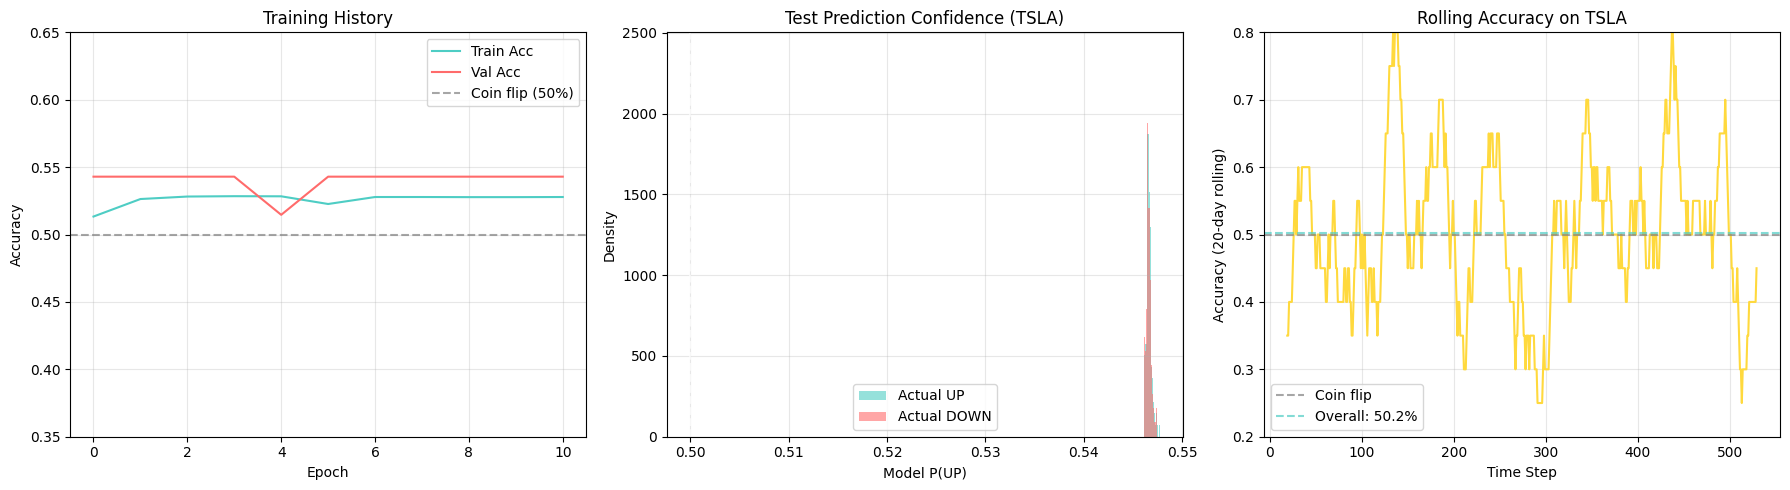


SUMMARY
  Coin flip baseline:   50.0%
  Validation accuracy:  54.3%
  Test accuracy (TSLA): 50.2%

  Barely above coin flip. Not tradeable.


In [ ]:
########################################################################
# DIRECTION PREDICTION: Can the Transformer predict UP vs DOWN?
# Paste this into a new cell AFTER sections 1-3 (data loading/alignment)
# It reuses the `stocks` dict already in memory.
########################################################################

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

# ========================
# CONFIG
# ========================
HOLDOUT_STOCK = 'TSLA'
SEQUENCE_LENGTH = 60
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 0.0005
TRAIN_CUTOFF = '2024-01-01'
FEATURE_COLS = ['Open', 'High', 'Low', 'Close', 'Volume']

# ========================
# DATASET: predict UP (1) or DOWN (0)
# ========================
class DirectionDataset(Dataset):
    """
    Input: 60 days of OHLCV features (scaled 0-1)
    Target: 1 if close[day 61] > close[day 60], else 0

    This is the HARD problem. The model can't cheat by echoing
    yesterday's price — it must predict the direction of change.
    """
    def __init__(self, features, closes_raw, seq_len):
        self.features = torch.FloatTensor(features)
        self.closes_raw = closes_raw  # unscaled closes for direction calc
        self.seq_len = seq_len

        # Compute direction labels: is tomorrow's close > today's close?
        self.labels = []
        for i in range(len(closes_raw) - seq_len):
            today_close = closes_raw[i + seq_len - 1]
            tomorrow_close = closes_raw[i + seq_len]
            self.labels.append(1.0 if tomorrow_close > today_close else 0.0)
        self.labels = torch.FloatTensor(self.labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.features[idx:idx + self.seq_len]
        y = self.labels[idx]
        return x, y


def prepare_direction_data(stocks, holdout_ticker, feature_cols, train_cutoff, seq_len):
    """Prepare train/val/test for direction prediction."""
    train_datasets, val_datasets, test_datasets = [], [], []
    cutoff_date = pd.Timestamp(train_cutoff)
    close_idx = feature_cols.index('Close')

    stats = {'train_up': 0, 'train_total': 0, 'val_up': 0, 'val_total': 0,
             'test_up': 0, 'test_total': 0}

    for ticker, df in stocks.items():
        train_mask = df['Date'] < cutoff_date
        val_mask = df['Date'] >= cutoff_date

        train_raw = df[train_mask][feature_cols].values
        val_raw = df[val_mask][feature_cols].values

        # Raw closes (unscaled) for computing direction
        train_closes_raw = df[train_mask]['Close'].values
        val_closes_raw = df[val_mask]['Close'].values

        # Scale features
        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_raw)
        val_scaled = scaler.transform(val_raw)

        if ticker == holdout_ticker:
            # Test set: lead-in from training + val period
            combined_scaled = np.concatenate([train_scaled[-seq_len:], val_scaled], axis=0)
            combined_closes = np.concatenate([train_closes_raw[-seq_len:], val_closes_raw], axis=0)
            ds = DirectionDataset(combined_scaled, combined_closes, seq_len)
            test_datasets.append(ds)
            stats['test_up'] += int(ds.labels.sum().item())
            stats['test_total'] += len(ds)
            print(f"  {ticker} [TEST]:  {len(ds)} samples, "
                  f"{ds.labels.sum().item()/len(ds)*100:.1f}% up days")
        else:
            # Training set
            train_ds = DirectionDataset(train_scaled, train_closes_raw, seq_len)
            train_datasets.append(train_ds)
            stats['train_up'] += int(train_ds.labels.sum().item())
            stats['train_total'] += len(train_ds)

            # Validation set
            combined_scaled = np.concatenate([train_scaled[-seq_len:], val_scaled], axis=0)
            combined_closes = np.concatenate([train_closes_raw[-seq_len:], val_closes_raw], axis=0)
            val_ds = DirectionDataset(combined_scaled, combined_closes, seq_len)
            val_datasets.append(val_ds)
            stats['val_up'] += int(val_ds.labels.sum().item())
            stats['val_total'] += len(val_ds)

            print(f"  {ticker} [TRAIN]: {len(train_ds)} train, {len(val_ds)} val, "
                  f"{train_ds.labels.sum().item()/len(train_ds)*100:.1f}% up days")

    train_dataset = ConcatDataset(train_datasets)
    val_dataset = ConcatDataset(val_datasets)
    test_dataset = ConcatDataset(test_datasets)

    print(f"\n  Dataset sizes: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")
    print(f"  Train class balance: {stats['train_up']/stats['train_total']*100:.1f}% up")
    print(f"  Val class balance:   {stats['val_up']/stats['val_total']*100:.1f}% up")
    print(f"  Test class balance:  {stats['test_up']/stats['test_total']*100:.1f}% up")
    print(f"\n  >>> A coin flip would get ~50% accuracy <<<")
    print(f"  >>> Always predicting 'up' would get ~{stats['test_up']/stats['test_total']*100:.1f}% on test <<<")

    return train_dataset, val_dataset, test_dataset, stats


# ========================
# TRANSFORMER CLASSIFIER
# ========================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class DirectionTransformer(nn.Module):
    """
    Transformer encoder that outputs a single probability: P(up).
    Uses sigmoid output + BCELoss for binary classification.
    """
    def __init__(self, num_features=5, d_model=64, nhead=4, num_layers=3,
                 dim_ff=256, seq_len=60, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(num_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=seq_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classification head: use [CLS]-like pooling (last time step)
        self.norm = nn.LayerNorm(d_model)
        self.fc1 = nn.Linear(d_model, 64)
        self.fc2 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = self.norm(x[:, -1, :])  # Take last time step
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x.squeeze(-1)  # Raw logits (use BCEWithLogitsLoss)


# ========================
# TRAINING
# ========================
def train_direction_model(model, train_loader, val_loader, epochs, lr):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    best_val_acc = 0
    best_state = None
    patience_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # Train
        model.train()
        train_losses, train_correct, train_total = [], 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())
            preds = (torch.sigmoid(logits) > 0.5).float()
            train_correct += (preds == y).sum().item()
            train_total += len(y)

        # Validate
        model.eval()
        val_losses, val_correct, val_total = [], 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                val_losses.append(loss.item())
                preds = (torch.sigmoid(logits) > 0.5).float()
                val_correct += (preds == y).sum().item()
                val_total += len(y)

        train_acc = train_correct / train_total
        val_acc = val_correct / val_total
        avg_val_loss = np.mean(val_losses)

        history['train_loss'].append(np.mean(train_losses))
        history['train_acc'].append(train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        scheduler.step(avg_val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Acc: {train_acc*100:.1f}% | Val Acc: {val_acc*100:.1f}% | "
                  f"Train Loss: {np.mean(train_losses):.4f} | Val Loss: {avg_val_loss:.4f}")

        if patience_counter >= 10:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    if best_state:
        model.load_state_dict(best_state)
    print(f"\n  Best validation accuracy: {best_val_acc*100:.1f}%")
    return model, history


# ========================
# EVALUATION
# ========================
def evaluate_direction(model, loader, label='Test'):
    model.eval()
    all_preds, all_targets, all_probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_targets, all_preds)
    print(f"\n{'='*60}")
    print(f"  {label} RESULTS")
    print(f"{'='*60}")
    print(f"  Accuracy: {acc*100:.1f}%")
    print(f"  Coin flip baseline: 50.0%")
    print(f"  Always-up baseline: {all_targets.mean()*100:.1f}%")
    print(f"  Improvement over coin flip: {(acc - 0.5)*100:+.1f} percentage points")
    print(f"\n  Classification Report:")
    print(classification_report(all_targets, all_preds,
          target_names=['DOWN', 'UP'], digits=3))

    # Confusion matrix
    cm = confusion_matrix(all_targets, all_preds)
    print(f"  Confusion Matrix:")
    print(f"                Predicted DOWN  Predicted UP")
    print(f"  Actual DOWN   {cm[0,0]:>12}  {cm[0,1]:>12}")
    print(f"  Actual UP     {cm[1,0]:>12}  {cm[1,1]:>12}")

    return all_preds, all_targets, all_probs, acc


# ========================
# RUN EVERYTHING
# ========================
print("="*60)
print("DIRECTION PREDICTION: UP vs DOWN")
print("Can the Transformer beat a coin flip?")
print("="*60)

print("\n--- Preparing direction data ---")
train_ds, val_ds, test_ds, stats = prepare_direction_data(
    stocks, HOLDOUT_STOCK, FEATURE_COLS, TRAIN_CUTOFF, SEQUENCE_LENGTH
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("\n--- Training Direction Transformer ---")
model = DirectionTransformer(num_features=len(FEATURE_COLS), seq_len=SEQUENCE_LENGTH)
total_params = sum(p.numel() for p in model.parameters())
print(f"  Parameters: {total_params:,}\n")

model, history = train_direction_model(model, train_loader, val_loader, EPOCHS, LEARNING_RATE)

# Evaluate
val_preds, val_targets, val_probs, val_acc = evaluate_direction(model, val_loader, 'VALIDATION (known stocks, 2024+)')
test_preds, test_targets, test_probs, test_acc = evaluate_direction(model, test_loader, f'TEST (holdout: {HOLDOUT_STOCK}, 2024+)')

# ========================
# PLOTS
# ========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Training curves
axes[0].plot(history['train_acc'], label='Train Acc', color='#4ecdc4')
axes[0].plot(history['val_acc'], label='Val Acc', color='#ff6b6b')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Coin flip (50%)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.35, 0.65)

# 2. Prediction confidence distribution
axes[1].hist(test_probs[test_targets == 1], bins=30, alpha=0.6, color='#4ecdc4', label='Actual UP', density=True)
axes[1].hist(test_probs[test_targets == 0], bins=30, alpha=0.6, color='#ff6b6b', label='Actual DOWN', density=True)
axes[1].axvline(x=0.5, color='white', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Model P(UP)')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Test Prediction Confidence ({HOLDOUT_STOCK})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Rolling accuracy over time
window = 20
rolling_correct = pd.Series((test_preds == test_targets).astype(float)).rolling(window).mean()
axes[2].plot(rolling_correct, color='#ffd93d', linewidth=1.5)
axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Coin flip')
axes[2].axhline(y=test_acc, color='#4ecdc4', linestyle='--', alpha=0.7, label=f'Overall: {test_acc*100:.1f}%')
axes[2].set_xlabel('Time Step')
axes[2].set_ylabel(f'Accuracy ({window}-day rolling)')
axes[2].set_title(f'Rolling Accuracy on {HOLDOUT_STOCK}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0.2, 0.8)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"  Coin flip baseline:   50.0%")
print(f"  Validation accuracy:  {val_acc*100:.1f}%")
print(f"  Test accuracy (TSLA): {test_acc*100:.1f}%")
if test_acc > 0.53:
    print(f"\n  The model shows some edge over random chance.")
    print(f"  But in real trading, you'd need >55% with good risk management to profit.")
elif test_acc > 0.50:
    print(f"\n  Barely above coin flip. Not tradeable.")
else:
    print(f"\n  At or below coin flip. The model has NOT learned to predict direction.")
    print(f"  This confirms the price-prediction models were just echoing yesterday's price.")


---
## 15. Baseline Results Summary

### Price Prediction Results (Sections 7–12)

Five neural network architectures — CNN, RNN, LSTM, GRU, and Transformer — were trained on OHLCV data from four stocks (AAPL, GOOG, META, NVDA) from 2012–2023, validated on those same stocks in 2024+, and tested on a held-out stock (TSLA, 2024+).

| Model | Params | Epochs | Test RMSE | Test MAE |
|-------|--------|--------|-----------|----------|
| GRU | 159,233 | 27 | 0.0308 | 0.0233 |
| LSTM | 209,537 | 27 | 0.0317 | 0.0240 |
| RNN | 58,625 | 16 | 0.0375 | 0.0274 |
| CNN | 174,017 | 12 | 0.0390 | 0.0295 |
| Transformer | 642,113 | 14 | 0.0589 | 0.0421 |

At first glance, these results appear strong — the GRU predicts Tesla's normalized close price with ~2.3% average error on a stock it never trained on. However, this is misleading.

### Reality Check: Naive Baseline Comparison (Section 13)

A naive baseline that simply predicts "tomorrow's price = today's price" achieves an RMSE of **0.0281** — better than every trained model. All five architectures performed worse than this trivial strategy:

| Model | Test RMSE | vs Naive |
|-------|-----------|----------|
| **Naive (copy yesterday)** | **0.0281** | **baseline** |
| GRU | 0.0308 | -9.6% worse |
| LSTM | 0.0317 | -12.8% worse |
| RNN | 0.0375 | -33.4% worse |
| CNN | 0.0390 | -38.7% worse |
| Transformer | 0.0589 | -109.8% worse |

Correlation analysis confirmed that all model outputs are nearly identical to the naive prediction (r > 0.99 for all models). The networks effectively learned to echo the previous day's closing price — a strategy that produces visually impressive prediction charts but contains no actual predictive signal.

### Direction Prediction Test (Section 14)

To test whether the models captured any genuine predictive ability, a Transformer classifier was trained to predict the **direction** of price movement (up vs. down) rather than the price itself. This is the task that matters for trading — predicting whether a stock will go up or down.

| Metric | Result |
|--------|--------|
| Coin flip baseline | 50.0% |
| Always-predict-up baseline | 50.2% |
| Transformer test accuracy | **50.2%** |

The model achieved 50.2% accuracy on Tesla — identical to always predicting "up." The confusion matrix confirmed this: the model predicted "UP" for all 530 test days and never once predicted "DOWN." It did not learn any directional signal.

### Conclusions

1. **Price prediction with 1-day horizon is a misleading benchmark.** Stock prices are highly autocorrelated (today ≈ yesterday), so any model that learns to approximate the identity function will appear accurate. This is a well-documented issue in time series forecasting literature.

2. **None of the baseline architectures learned meaningful predictive patterns.** All five models performed worse than a naive copy-yesterday strategy, and a dedicated direction classifier could not beat a coin flip.

3. **These results establish honest baselines.** Future improvements — such as incorporating sentiment analysis, technical indicators, longer forecast horizons, or return-based targets — should be evaluated against:
   - **Price prediction:** Naive RMSE of 0.0281 (must beat this to show the model adds value)
   - **Direction prediction:** 50% accuracy (must significantly exceed coin-flip to demonstrate real signal)

4. **Simpler models generalized better than complex ones.** Among the price-prediction models, GRU (2 gates, 159K params) outperformed the Transformer (self-attention, 642K params), consistent with the bias-variance tradeoff on limited training data (~11K sequences).